# Beschreibung #

# LDA-Eigenwerte fuer Tennessee Eastman Process (TEP)

Dieses Notebook berechnet fuer jede Fehlerklasse (`faultNumber` 0-20) und jeden
Simulationslauf (`simulationRun`) den **LDA-Eigenwert** (Diskriminanz-Eigenwert)
des jeweiligen Runs und fasst diesen anschliessend ueber die 500 Laeufe pro
Fehlerklasse mittels Mittelwert und Standardabweichung zusammen.

**Datensatz**

Kaggle "tep-csv" (afrniomelo):
https://www.kaggle.com/datasets/afrniomelo/tep-csv

- `TEP_FaultFree_Training.csv`  (faultNumber = 0)
- `TEP_Faulty_Training.csv`     (faultNumber = 1..20)

Beide Dateien muessen im aktuellen Arbeitsverzeichnis liegen.

Eigenschaften des Datensatzes (laut Kaggle-Doku):
- Sampling-Intervall: alle 3 Minuten.
- Training: 500 Samples pro Run (= 25 h Simulationsdauer).
- Faulty Training: Fehler wird **1 Stunde nach Simulationsstart** injiziert
  -> 60 min / 3 min = **20 Samples Vorlauf**, erstes Post-Fault-Sample ist
  `sample == 21`.

**Konzeptioneller Unterschied zu PCA / DyCA**

PCA und DyCA sind *unueberwacht*: sie liefern pro Run einen vollstaendigen
Eigenwertvektor (52 Werte = Anzahl Prozessvariablen). LDA ist dagegen
*ueberwacht* und braucht Klassen-Labels. Die Zahl der von Null verschiedenen
LDA-Eigenwerte ist `min(Anzahl_Klassen - 1, Anzahl_Features)`.

Hier wird LDA pro Run als **2-Klassen-Problem** aufgesetzt:

- **Klasse 0 (Normal):** ein FaultFree-Referenzlauf (Normalbetrieb).
- **Klasse 1 (Fault):**  die Post-Fault-Daten des betrachteten Runs.

Damit gibt es genau **einen** von Null verschiedenen LDA-Eigenwert pro Run.
Dieser Eigenwert ist Fishers Diskriminanz-Verhaeltnis (Separierbarkeit
zwischen Normal- und Fehlerklasse) und entspricht - bis auf einen Faktor -
der Mahalanobis-Distanz der Klassenmittel unter der gepoolten
Within-Class-Kovarianz. Grosser Eigenwert = staerker abgrenzbarer Fehler.

**Vorgehen**

- Ein `StandardScaler` wird **nur** auf Normalbetrieb (`faultNumber == 0`) aus
  `TEP_FaultFree_Training.csv` gefittet. Damit sind alle Klassen in derselben
  Skalierungseinheit (Normalbetriebs-Std) -> untereinander vergleichbar.
- **Run-Matching:** Fuer Fault `f`, Run `r` ist die Referenzklasse (Normal)
  der gleich indizierte FaultFree-Lauf `r` (eigenstaendige Normal-Simulation,
  500 Samples). Klasse 1 sind die Post-Fault-Daten von Fault `f`, Run `r`
  (480 Samples).
- **Sonderfall Fault 0:** Hier existiert kein echter Fehler. Als Baseline wird
  Lauf `r` gegen den naechsten FaultFree-Lauf (`r+1`) gestellt
  (Normal-gegen-Normal). Der resultierende Eigenwert liegt erwartungsgemaess
  nahe Null und dient als Vergleichs-Nulllinie.
- Bei Fehlerklassen 1-20 werden die **Pre-Fault-Samples** (`sample < 21`)
  verworfen.
- Der eine LDA-Eigenwert wird ueber das verallgemeinerte Eigenwertproblem
  `Sb v = lambda Sw v` bestimmt (geschlossene Form fuer 2 Klassen). Eine
  kleine Ridge-Regularisierung auf `Sw` sichert die numerische Invertierbarkeit.
- Ueber die 500 Laeufe einer Fehlerklasse werden Mittelwert und
  Standardabweichung des Eigenwerts gebildet.

**Hinweis zu den Plots:** Da pro Run nur *ein* Eigenwert existiert, gibt es
kein Spektrum ueber Komponenten wie bei PCA/DyCA. Die Visualisierungen
(Mittelwert, Standardabweichung, Variationskoeffizient, Balken mit
Fehlerbalken) tragen daher die **Fehlerklasse** auf der x-Achse auf.


# Imports #

In [1]:
# !pip install matplotlib numpy pandas scikit-learn scipy tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

# scipy nur fuer die Typ-/Doku-Naehe importiert; die geschlossene Form
# unten nutzt np.linalg.solve. (scipy ist ohnehin eine sklearn-Abhaengigkeit.)
import scipy.linalg  # noqa: F401

# Optional: Fortschrittsbalken fuer lange Schleifen
try:
    from tqdm.auto import tqdm
    tqdm_available = True
except ImportError:
    tqdm_available = False

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 10

d:\CCS\Forschung\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Parameter #

In [2]:
# ===== Pfade zu den TEP-CSV-Dateien =====
PATH_FAULTFREE_TRAIN = "TEP_FaultFree_Training.csv"
PATH_FAULTY_TRAIN    = "TEP_Faulty_Training.csv"

# ===== Prozessvariablen (wie im PCA-/DyCA-Notebook) =====
XMEAS_COLS = [f"xmeas_{i}" for i in range(1, 42)]
XMV_COLS   = [f"xmv_{i}"   for i in range(1, 12)]
PROC_COLS  = XMEAS_COLS + XMV_COLS

META_COLS  = ["faultNumber", "simulationRun", "sample"]

# ===== LDA-/Verfahrens-Parameter =====
# Erster Sample-Index, der als 'post-fault' gilt (siehe Beschreibung).
PRE_FAULT_CUTOFF = 21

# Relative Ridge-Regularisierung der Within-Class-Streumatrix Sw:
#   Sw <- Sw + RIDGE_REL * (trace(Sw)/p) * I
# Stabilisiert die Inversion, falls Sw nahe rangdefizient ist (die 52
# TEP-Variablen sind durch Massen-/Stoffbilanzen quasi-linear abhaengig).
RIDGE_REL = 1e-6

# Daten laden & Spalten pruefen #

In [3]:
# ============================================================
# Trainingsdaten laden
# ============================================================
#   - TEP_FaultFree_Training.csv : nur faultNumber == 0
#     -> 500 simulationRuns x 500 samples = 250 000 Zeilen
#   - TEP_Faulty_Training.csv    : faultNumber 1..20
#     -> 20 faults x 500 runs x 500 samples = 5 000 000 Zeilen

df_ff_train     = pd.read_csv(PATH_FAULTFREE_TRAIN)
df_faulty_train = pd.read_csv(PATH_FAULTY_TRAIN)

# Nur benoetigte Spalten behalten (Metadaten + Prozessvariablen).
df_ff_train     = df_ff_train[META_COLS + PROC_COLS]
df_faulty_train = df_faulty_train[META_COLS + PROC_COLS]

print("FaultFree_Training shape:", df_ff_train.shape)
print("Faulty_Training shape   :", df_faulty_train.shape)

# ------------------------------------------------------------
# Spalten-Check
# ------------------------------------------------------------
for col in META_COLS:
    if col not in df_ff_train.columns:
        raise ValueError(f"Spalte {col} fehlt in TEP_FaultFree_Training.csv")
    if col not in df_faulty_train.columns:
        raise ValueError(f"Spalte {col} fehlt in TEP_Faulty_Training.csv")

print("Anzahl Prozessvariablen:", len(PROC_COLS))
print("Beispiel-Variablen:", PROC_COLS[:5])

FaultFree_Training shape: (250000, 55)
Faulty_Training shape   : (5000000, 55)
Anzahl Prozessvariablen: 52
Beispiel-Variablen: ['xmeas_1', 'xmeas_2', 'xmeas_3', 'xmeas_4', 'xmeas_5']


# Standardisierung auf FaultFree_Training #

In [4]:
# ============================================================
# StandardScaler auf FaultFree_Training (Normalbetrieb) fitten
# ============================================================
# Damit liegen Normal- und Fehlerklasse in derselben Skalierungseinheit
# (Normalbetriebs-Std). Das ist fuer LDA besonders wichtig, weil der
# Eigenwert (Separierbarkeit) skalenabhaengig ist.

scaler = StandardScaler()
scaler.fit(df_ff_train[PROC_COLS].values)

print("StandardScaler auf FaultFree_Training angepasst.")
print("  Anzahl Features:      ", len(PROC_COLS))
print("  Mittelwerte (Auszug): ", np.round(scaler.mean_[:5], 4))
print("  Std-Werte (Auszug):   ", np.round(scaler.scale_[:5], 4))

StandardScaler auf FaultFree_Training angepasst.
  Anzahl Features:       52
  Mittelwerte (Auszug):  [2.5050000e-01 3.6637857e+03 4.5088198e+03 9.3471000e+00 2.6902200e+01]
  Std-Werte (Auszug):    [3.09000e-02 3.40063e+01 3.92153e+01 8.57000e-02 2.11500e-01]


# FaultFree-Referenzlaeufe vorbereiten #

In [5]:
# ============================================================
# Pro FaultFree-Lauf die standardisierte Messmatrix vorberechnen
# ============================================================
# Diese Laeufe dienen als Klasse 0 (Normal) in der LDA. Vorberechnen
# spart in der Hauptschleife wiederholtes Filtern/Transformieren.
#
# ff_by_run[r] -> np.ndarray shape (n_samples_r, 52), standardisiert.

ff_by_run = {}
for run, g in df_ff_train.groupby("simulationRun"):
    g = g.sort_values("sample")
    ff_by_run[run] = scaler.transform(g[PROC_COLS].values)

ff_run_ids = sorted(ff_by_run.keys())
print("Anzahl FaultFree-Referenzlaeufe:", len(ff_run_ids))
print("Beispiel-Run-Index:", ff_run_ids[0],
      "-> shape:", ff_by_run[ff_run_ids[0]].shape)

Anzahl FaultFree-Referenzlaeufe: 500
Beispiel-Run-Index: 1 -> shape: (500, 52)


# Trainingsdaten zusammenfuehren (Fault 0-20) #

In [6]:
# ============================================================
# Trainingsdaten zusammenfuehren (Fault 0..20 in EINEM DataFrame)
# ============================================================
# Eine Schleife laeuft anschliessend ueber alle (faultNumber,
# simulationRun)-Kombinationen. Fuer Fault 0 wird die Referenz aus
# ff_by_run gezogen (siehe Hauptschleife), fuer Fault 1-20 liefert die
# Gruppe die Fehlerklasse.

df_all = pd.concat([df_ff_train, df_faulty_train], ignore_index=True)
df_all = df_all.sort_values(
    ["faultNumber", "simulationRun", "sample"]
).reset_index(drop=True)

print("Kombinierte Trainingsdaten shape:", df_all.shape)
print("FaultNumbers im kombinierten Datensatz:",
      sorted(df_all["faultNumber"].unique()))

Kombinierte Trainingsdaten shape: (5250000, 55)
FaultNumbers im kombinierten Datensatz: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]


# Funktion: LDA-Eigenwert pro Run #

In [7]:
def compute_lda_eigenvalue(X0, X1, ridge_rel=RIDGE_REL):
    """
    Berechnet den einzigen von Null verschiedenen LDA-Eigenwert eines
    2-Klassen-Problems (Klasse 0 = Normal, Klasse 1 = Fault).

    Mathematik
    ----------
    Within-Class-Streumatrix (summiert, nicht gemittelt):
        Sw = sum_i (x0_i - m0)(x0_i - m0)^T + sum_j (x1_j - m1)(x1_j - m1)^T
    Between-Class-Streumatrix (2 Klassen -> Rang 1):
        Sb = (n0 n1 / (n0 + n1)) (m1 - m0)(m1 - m0)^T
    Verallgemeinertes Eigenwertproblem  Sb v = lambda Sw v. Da Sb Rang 1
    hat, gibt es genau einen Eigenwert != 0; er ist gleich der Spur
    trace(Sw^-1 Sb) und damit geschlossen berechenbar:
        lambda = (n0 n1 / (n0 + n1)) * (m1 - m0)^T Sw^-1 (m1 - m0)

    Das ist Fishers Diskriminanz-Verhaeltnis bzw. (bis auf den Faktor)
    die quadrierte Mahalanobis-Distanz der Klassenmittel.

    Parameter
    ---------
    X0, X1 : np.ndarray
        Standardisierte Messmatrizen (n_samples x n_features) der
        Klassen 0 (Normal) und 1 (Fault).
    ridge_rel : float
        Relative Ridge-Regularisierung von Sw (numerische Stabilitaet).

    Rueckgabewert
    -------------
    lam : float
        Der LDA-Eigenwert (Separierbarkeit, >= 0).
    """
    n0 = X0.shape[0]
    n1 = X1.shape[0]

    m0 = X0.mean(axis=0)
    m1 = X1.mean(axis=0)

    # Within-Class-Streumatrix (Summe der klassenzentrierten Aussenprodukte).
    X0c = X0 - m0
    X1c = X1 - m1
    Sw = X0c.T @ X0c + X1c.T @ X1c

    # Ridge-Regularisierung: stabilisiert die Inversion bei nahe
    # rangdefizitem Sw (quasi-lineare Abhaengigkeiten der TEP-Variablen).
    p = Sw.shape[0]
    Sw = Sw + ridge_rel * (np.trace(Sw) / p) * np.eye(p)

    # Geschlossene Form des einzigen nicht-null Eigenwerts.
    d = m1 - m0
    lam = (n0 * n1 / (n0 + n1)) * float(d @ np.linalg.solve(Sw, d))
    return lam


def compute_lda_eigenvalues_per_run(df, ff_by_run, proc_cols, scaler,
                                    ridge_rel=RIDGE_REL,
                                    drop_pre_fault=True,
                                    pre_fault_cutoff=PRE_FAULT_CUTOFF):
    """
    Erzeugt einen DataFrame mit dem LDA-Eigenwert pro
    (faultNumber, simulationRun).

    Klassenaufbau pro Run:
      - Fault 0:   Klasse 1 = FaultFree-Lauf r, Klasse 0 = FaultFree-Lauf r+1
                   (Normal-gegen-Normal-Baseline).
      - Fault !=0: Klasse 1 = Post-Fault-Daten (sample >= pre_fault_cutoff),
                   Klasse 0 = FaultFree-Lauf r (Run-Matching).

    Rueckgabewert
    -------------
    df_eigs : pd.DataFrame
        Spalten: 'faultNumber', 'simulationRun', 'lda_eigenvalue'.
    """
    ff_run_ids = sorted(ff_by_run.keys())

    def neighbor(r):
        # Naechster FaultFree-Lauf (zyklisch) - fuer die Fault-0-Baseline.
        i = ff_run_ids.index(r)
        return ff_run_ids[(i + 1) % len(ff_run_ids)]

    grouped = df.groupby(["faultNumber", "simulationRun"], sort=True)

    iterator = grouped
    if tqdm_available:
        iterator = tqdm(grouped, desc="Berechne LDA-Eigenwert pro Run")

    records      = []
    error_count  = 0
    first_errors = []

    for (fault, run), group in iterator:
        try:
            if fault == 0:
                # Baseline: Normal-Lauf r gegen Normal-Lauf r+1.
                X1 = ff_by_run[run]
                X0 = ff_by_run[neighbor(run)]
            else:
                # Klasse 1 = Post-Fault-Daten dieses Runs.
                g = group
                if drop_pre_fault:
                    g = g[g["sample"] >= pre_fault_cutoff]
                X1 = scaler.transform(g[proc_cols].values)
                # Klasse 0 = run-gematchter FaultFree-Lauf.
                X0 = ff_by_run[run]

            lam = compute_lda_eigenvalue(X0, X1, ridge_rel=ridge_rel)
            records.append({
                "faultNumber":    fault,
                "simulationRun":  run,
                "lda_eigenvalue": float(lam),
            })
        except Exception as e:
            error_count += 1
            if len(first_errors) < 5:
                first_errors.append(f"  fault={fault}, run={run}: {e}")

    df_eigs = pd.DataFrame.from_records(records)

    print("Erfolgreiche Runs:", len(df_eigs))
    print("Fehler          :", error_count)
    if first_errors:
        print("Erste Fehler:")
        for line in first_errors:
            print(line)

    return df_eigs

# Anwendung: LDA-Eigenwert fuer alle (Fault, Run)-Kombinationen #

In [8]:
# LDA-Eigenwert fuer alle Faults und Runs berechnen.
#
# Pre-Fault-Cutoff = 21:
#   Laut Kaggle-Doku (afrniomelo/tep-csv) wird der Fehler im Faulty
#   Training 1 Stunde nach Simulationsstart injiziert. Bei 3-min-Sampling
#   entspricht das 20 Samples Vorlauf; erstes Post-Fault-Sample = 21.

lda_eigenvalues_per_run = compute_lda_eigenvalues_per_run(
    df=df_all,
    ff_by_run=ff_by_run,
    proc_cols=PROC_COLS,
    scaler=scaler,
    ridge_rel=RIDGE_REL,
    drop_pre_fault=True,
    pre_fault_cutoff=PRE_FAULT_CUTOFF,
)

print("LDA-Eigenwerte pro Run shape:", lda_eigenvalues_per_run.shape)
lda_eigenvalues_per_run.head()

Berechne LDA-Eigenwert pro Run: 100%|██████████| 10500/10500 [00:28<00:00, 362.43it/s]


Erfolgreiche Runs: 10500
Fehler          : 0
LDA-Eigenwerte pro Run shape: (10500, 3)


,faultNumber,simulationRun,lda_eigenvalue
0,0,1,0.761517
1,0,2,0.390398
2,0,3,0.064567
3,0,4,0.118589
4,0,5,0.140603


# Aggregation: Mittelwert & Standardabweichung pro Fehlerklasse #

In [9]:
# ============================================================
# Pro Fehlerklasse: Mittelwert und Standardabweichung des LDA-Eigenwerts
# ============================================================
# Ausgangspunkt: eine Zeile pro (Fault, Run) mit Spalte 'lda_eigenvalue'.
# Ziel:          eine Zeile pro Fault mit Mittelwert, Std und Anzahl Runs.
# pandas-Std benutzt ddof=1 (Stichproben-Std), passt fuer N=500.

agg = (
    lda_eigenvalues_per_run
    .groupby("faultNumber")["lda_eigenvalue"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .rename(columns={"mean": "lda_mean", "std": "lda_std", "count": "n_runs"})
)

# Variationskoeffizient (relative Streuung) als zusaetzliche Spalte.
with np.errstate(divide="ignore", invalid="ignore"):
    agg["lda_cv"] = np.where(agg["lda_mean"] > 0,
                             agg["lda_std"] / agg["lda_mean"],
                             np.nan)

print("Aggregierte LDA-Eigenwert-Statistiken pro Fault:")
print("  shape:", agg.shape)
agg

Aggregierte LDA-Eigenwert-Statistiken pro Fault:
  shape: (21, 5)


,faultNumber,lda_mean,lda_std,n_runs,lda_cv
0,0,0.247902,0.177114,500,0.714453
1,1,37.117155,2.501876,500,0.067405
2,2,15.362001,1.107066,500,0.072065
3,3,0.055486,0.005066,500,0.091308
4,4,26.713255,1.808471,500,0.067699
5,5,81.305305,4.963435,500,0.061047
6,6,221.905786,36.819666,500,0.165925
7,7,42.708011,2.703000,500,0.063290
8,8,1.768851,0.859460,500,0.485886
9,9,0.003608,0.002251,500,0.623942


# Visualisierung: mittlerer LDA-Eigenwert je Fehlerklasse (Balken + Fehlerbalken) #

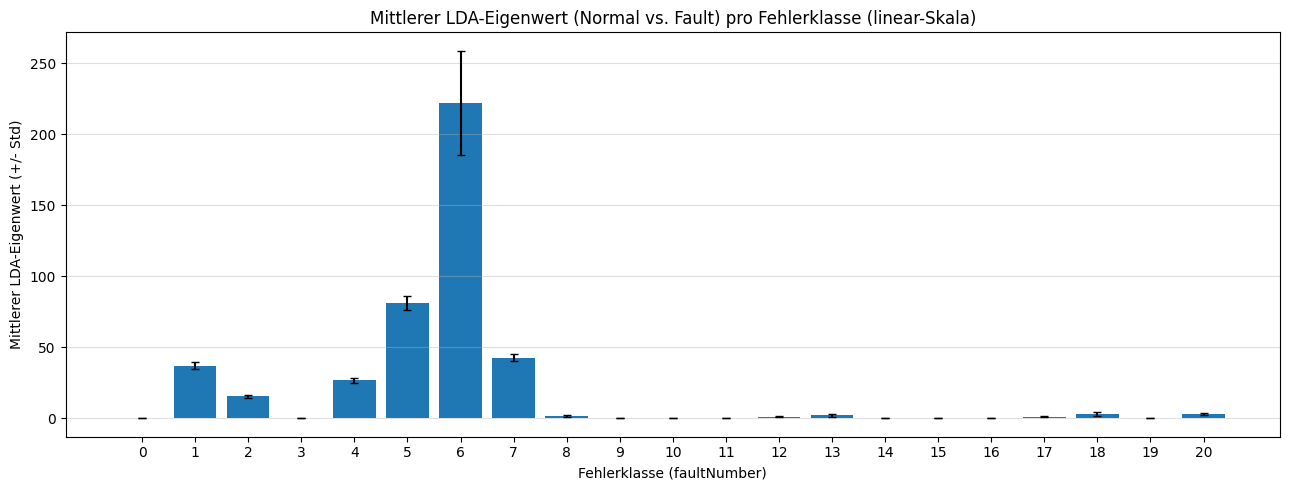

In [10]:
# ============================================================
# Balken-Plot: mittlerer LDA-Eigenwert (Separierbarkeit) je Fehlerklasse,
# Fehlerbalken = Standardabweichung ueber die Runs.
#
# Anders als bei PCA/DyCA gibt es pro Run nur EINEN Eigenwert, daher ein
# Balken pro Fehlerklasse (x-Achse = faultNumber) statt eines Spektrums.
# ============================================================

# Skala:
#   "linear" -> rohe Eigenwerte
#   "log"    -> log-Skala der y-Achse (Fault 0 ~ Baseline ist sehr klein,
#               starke Faults um Groessenordnungen groesser)
plot_mode = "linear"

faults = agg["faultNumber"].values
means  = agg["lda_mean"].values
stds   = agg["lda_std"].values

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(faults, means, yerr=stds, capsize=3, color="C0", ecolor="black")
ax.set_xticks(faults)
ax.set_xlabel("Fehlerklasse (faultNumber)")
ax.set_ylabel("Mittlerer LDA-Eigenwert (+/- Std)")
ax.grid(True, axis="y", alpha=0.4)

if plot_mode == "log":
    ax.set_yscale("log")

ax.set_title(
    f"Mittlerer LDA-Eigenwert (Normal vs. Fault) pro Fehlerklasse "
    f"({plot_mode}-Skala)"
)
plt.tight_layout()
plt.show()

# Visualisierung: Mittelwert & Standardabweichung im Vergleich #

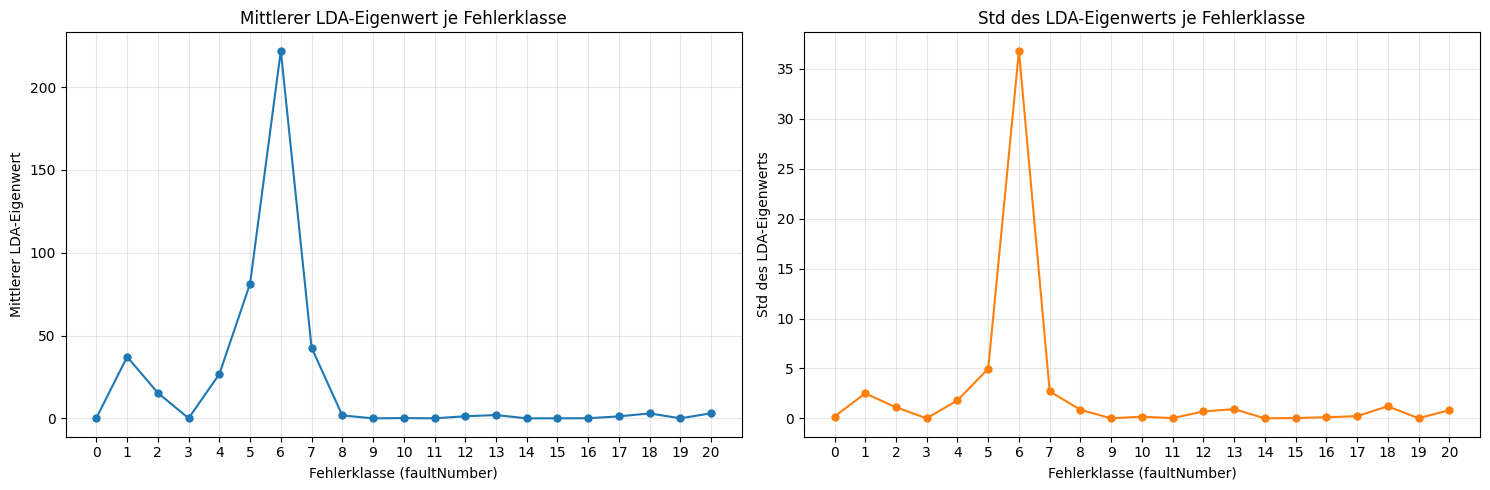

In [11]:
# ============================================================
# Zwei Subplots: links der Mittelwert, rechts die Standardabweichung des
# LDA-Eigenwerts ueber die Fehlerklassen. Struktur analog zu den
# Mittelwert-/Std-Plots im PCA-/DyCA-Notebook, hier mit faultNumber auf
# der x-Achse (da pro Run nur ein Eigenwert existiert).
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# --- Mittelwert ---
axes[0].plot(faults, means, "o-", color="C0", markersize=5)
axes[0].set_title("Mittlerer LDA-Eigenwert je Fehlerklasse")
axes[0].set_xlabel("Fehlerklasse (faultNumber)")
axes[0].set_ylabel("Mittlerer LDA-Eigenwert")
axes[0].set_xticks(faults)
axes[0].grid(True, alpha=0.3)

# --- Standardabweichung ---
axes[1].plot(faults, stds, "o-", color="C1", markersize=5)
axes[1].set_title("Std des LDA-Eigenwerts je Fehlerklasse")
axes[1].set_xlabel("Fehlerklasse (faultNumber)")
axes[1].set_ylabel("Std des LDA-Eigenwerts")
axes[1].set_xticks(faults)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualisierung: relative Streuung (Variationskoeffizient) je Fehlerklasse #

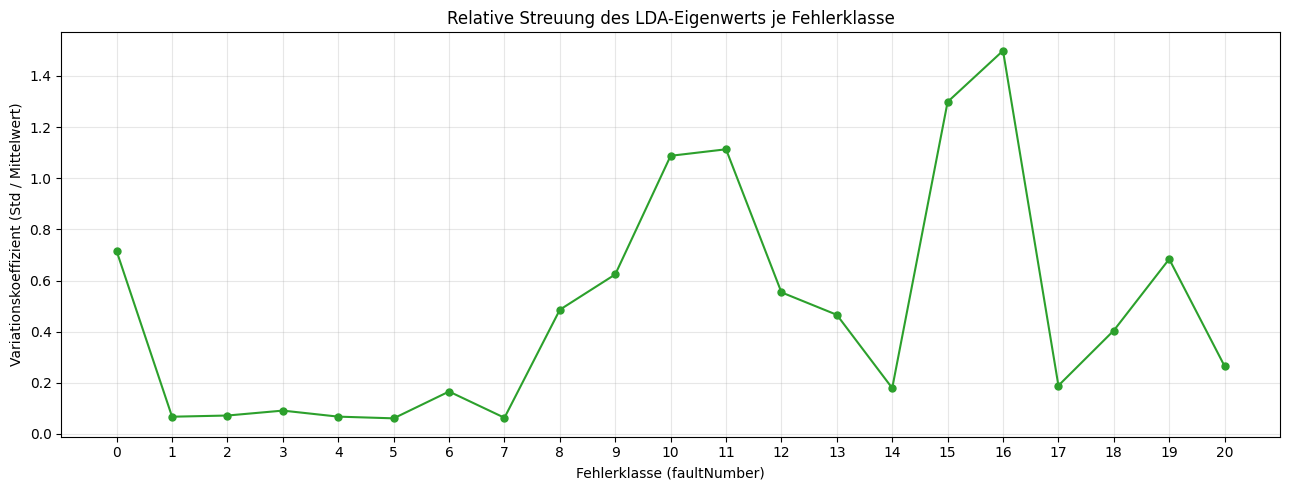

In [12]:
# ============================================================
# Variationskoeffizient  CV = Std / Mittelwert  je Fehlerklasse.
#   - Klein  -> Eigenwert ueber die Runs sehr stabil.
#   - Gross  -> starke Run-zu-Run-Schwankung der Fehlerauspraegung.
# Analog zum CV-Plot im PCA-/DyCA-Notebook (gruen), hier ueber faultNumber.
# ============================================================

cv = agg["lda_cv"].values

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(faults, cv, "o-", color="C2", markersize=5)
ax.set_xticks(faults)
ax.set_xlabel("Fehlerklasse (faultNumber)")
ax.set_ylabel("Variationskoeffizient (Std / Mittelwert)")
ax.grid(True, alpha=0.3)
ax.set_title("Relative Streuung des LDA-Eigenwerts je Fehlerklasse")

plt.tight_layout()
plt.show()